### Exploração — Sistema de Reservatório (MIMO)\n\nExploração inicial dos dados do sistema de reservatório de água usado em\n[Ferrari, Leandro & Coelho (2025)](../../docs/pappers/papper_allan_leandro-1.pdf),\n*\"Multi-objective metaheuristics applied for the multivariable system\nidentification\"*.\n\nO artigo identifica um sistema MIMO (Multiple-Input Multiple-Output) do tipo\nARMAX referente a um reservatório de distribuição de água (São José), usando\nmetaheurísticas mono e multiobjetivo (GA/NSGA-II, GWO/MOGWO, CS/MOCS).\n\nDados disponíveis em `data/raw/`:\n\n- `mimo_data.xlsx` — planilha do reservatório **São José** (sistema MIMO usado\n  no artigo): frequências das bombas (entradas) e vazão de entrada, vazão de\n  distribuição, nível e pressão do reservatório (saídas).\n- `miso_data.xls` — planilha do reservatório **Tarumã** (sistema MISO,\n  correntes de bombas x vazão), usado no estudo original ([26] citado no\n  artigo) do qual este trabalho é extensão.\n\nEste notebook cobre apenas a exploração (`notebooks/eda/`): carga, limpeza\nmínima, estatísticas descritivas e visualizações das séries temporais."

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_RAW = Path("../../data/raw")
MIMO_PATH = DATA_RAW / "mimo_data.xlsx"
MISO_PATH = DATA_RAW / "miso_data.xls"

In [2]:
mimo_cols = [
    "timestamp",
    "freq_b1",
    "freq_b2",
    "freq_b3",
    "vazao_entrada",
    "vazao_distribuicao",
    "nivel_res",
    "pressao",
]

mimo = pd.read_excel(MIMO_PATH, header=None, skiprows=3, names=mimo_cols)
mimo["timestamp"] = pd.to_datetime(mimo["timestamp"])
mimo = mimo.set_index("timestamp").sort_index()
mimo = mimo.apply(pd.to_numeric, errors="coerce")

print(mimo.shape)
mimo.head()

(2216, 7)


,freq_b1,freq_b2,freq_b3,vazao_entrada,vazao_distribuicao,nivel_res,pressao
timestamp,,,,,,,
2014-07-27 01:00:00,0.0,48.500000,0.0,59.161747,41.319435,2.313008,16.42
2014-07-27 02:00:00,0.0,48.500000,0.0,59.349953,36.163658,2.376330,16.42
2014-07-27 03:00:00,0.0,48.500000,0.0,38.935471,33.399830,2.433640,16.42
2014-07-27 04:00:00,0.0,45.197014,0.0,36.185631,32.003647,2.449207,16.00
2014-07-27 05:00:00,0.0,50.150032,0.0,36.003067,32.846390,2.458931,16.00


In [3]:
mimo.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2216 entries, 2014-07-27 01:00:00 to 2014-10-27 09:00:00
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   freq_b1             2208 non-null   float64
 1   freq_b2             2208 non-null   float64
 2   freq_b3             2208 non-null   float64
 3   vazao_entrada       2208 non-null   float64
 4   vazao_distribuicao  2208 non-null   float64
 5   nivel_res           2208 non-null   float64
 6   pressao             2208 non-null   float64
dtypes: float64(7)
memory usage: 138.5 KB


In [4]:
mimo.describe()

,freq_b1,freq_b2,freq_b3,vazao_entrada,vazao_distribuicao,nivel_res,pressao
count,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000
mean,31.265935,35.868844,3.392681,66.157330,67.644960,2.403007,22.173296
std,25.198973,23.849093,11.912819,34.236532,25.764200,0.295912,4.249852
min,0.000000,0.000000,0.000000,-0.000050,-20.107826,0.007118,0.231240
25%,0.000000,5.000000,0.000000,37.749400,41.560803,2.252698,19.636037
50%,46.221830,48.998888,0.000000,68.427586,70.224648,2.442053,21.920000
75%,53.799999,54.520961,0.000000,95.855494,88.786425,2.603691,25.989245
max,60.000000,60.000000,60.000000,200.162064,199.590027,3.029920,30.290001


### Valores ausentes e frequência de amostragem

In [5]:
print("Nulos por coluna (após coerção numérica):")
print(mimo.isna().sum())

print("\nPeríodo:", mimo.index.min(), "->", mimo.index.max())

deltas = mimo.index.to_series().diff().dropna()
print("\nFrequência de amostragem (contagem por intervalo):")
print(deltas.value_counts().head())

Nulos por coluna (após coerção numérica):
freq_b1               8
freq_b2               8
freq_b3               8
vazao_entrada         8
vazao_distribuicao    8
nivel_res             8
pressao               8
dtype: int64

Período: 2014-07-27 01:00:00 -> 2014-10-27 09:00:00

Frequência de amostragem (contagem por intervalo):
timestamp
0 days 01:00:00    2214
0 days 02:00:00       1
Name: count, dtype: int64


### Séries temporais — entradas (frequência das bombas) e saídas

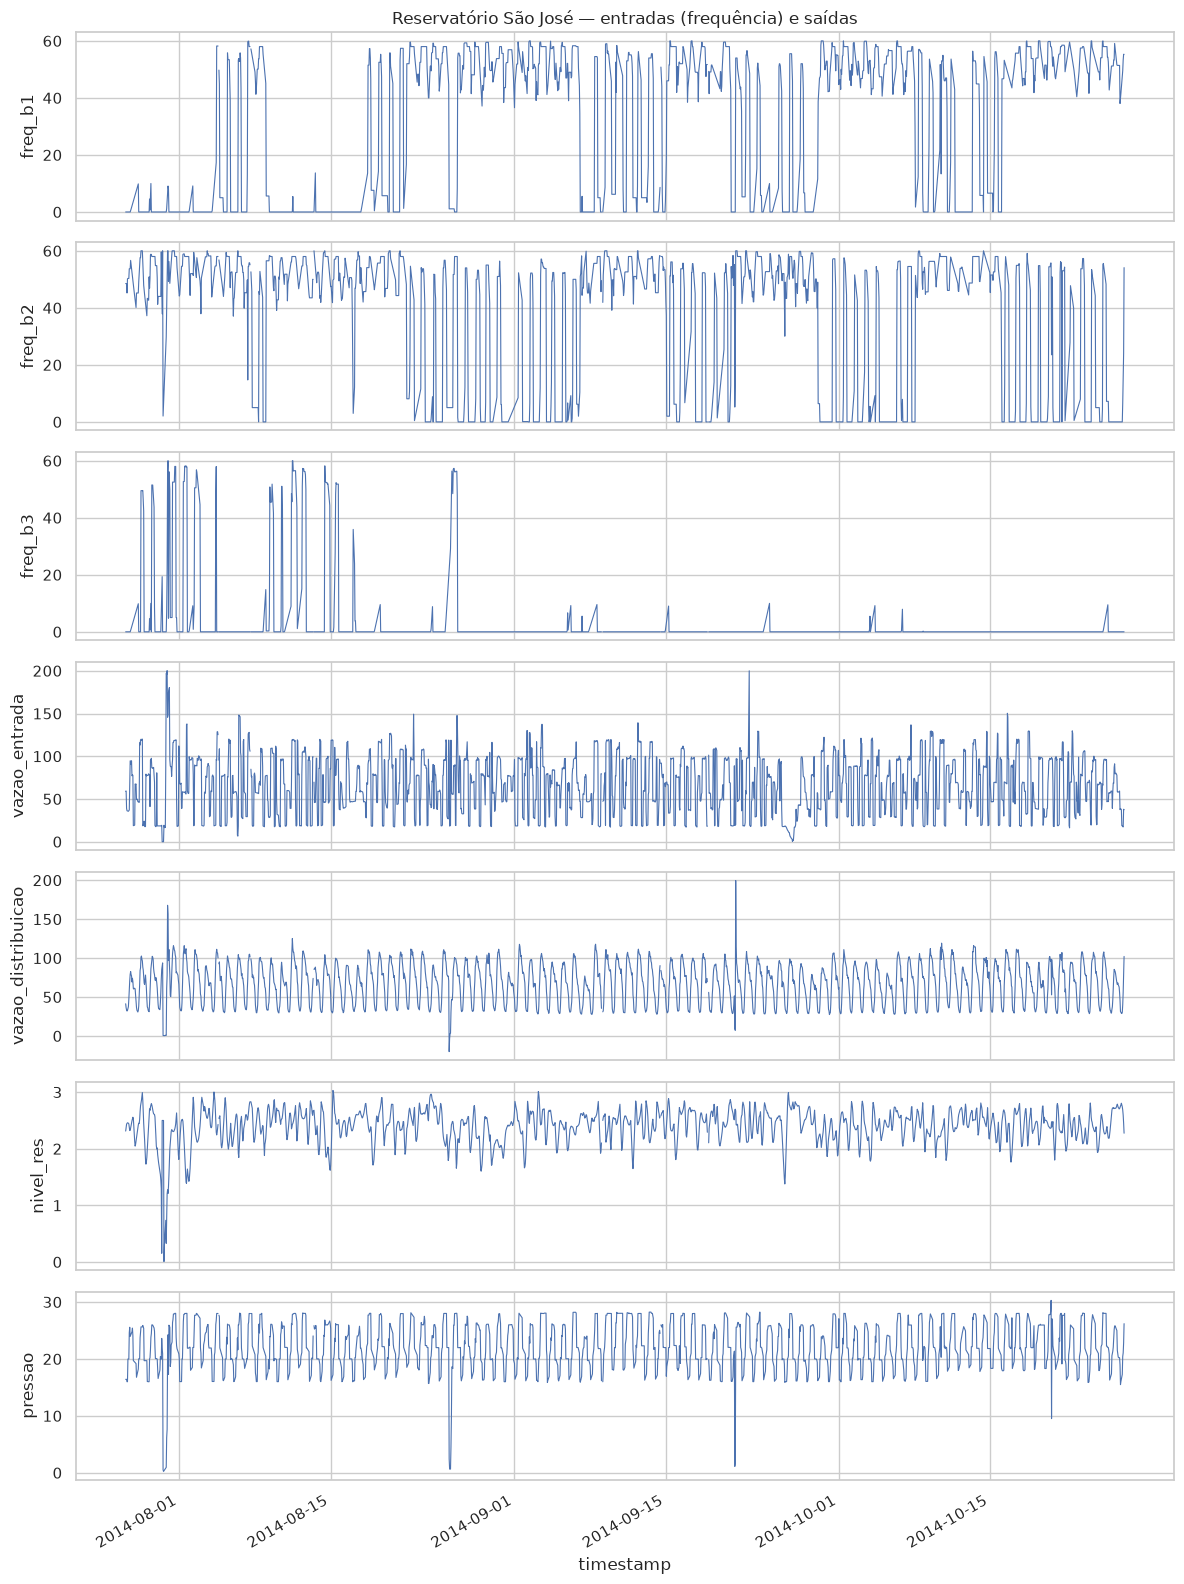

In [ ]:
inputs = ["freq_b1", "freq_b2", "freq_b3"]
outputs = ["vazao_entrada", "vazao_distribuicao", "nivel_res", "pressao"]

fig, axes = plt.subplots(
    len(inputs) + len(outputs), 1, figsize=(12, 16), sharex=True
)

for ax, col in zip(axes, inputs + outputs, strict=True):
    mimo[col].plot(ax=ax, linewidth=0.8)
    ax.set_ylabel(col)

axes[0].set_title("Reservatório São José — entradas (frequência) e saídas")
axes[-1].set_xlabel("timestamp")
fig.tight_layout()

### Distribuições

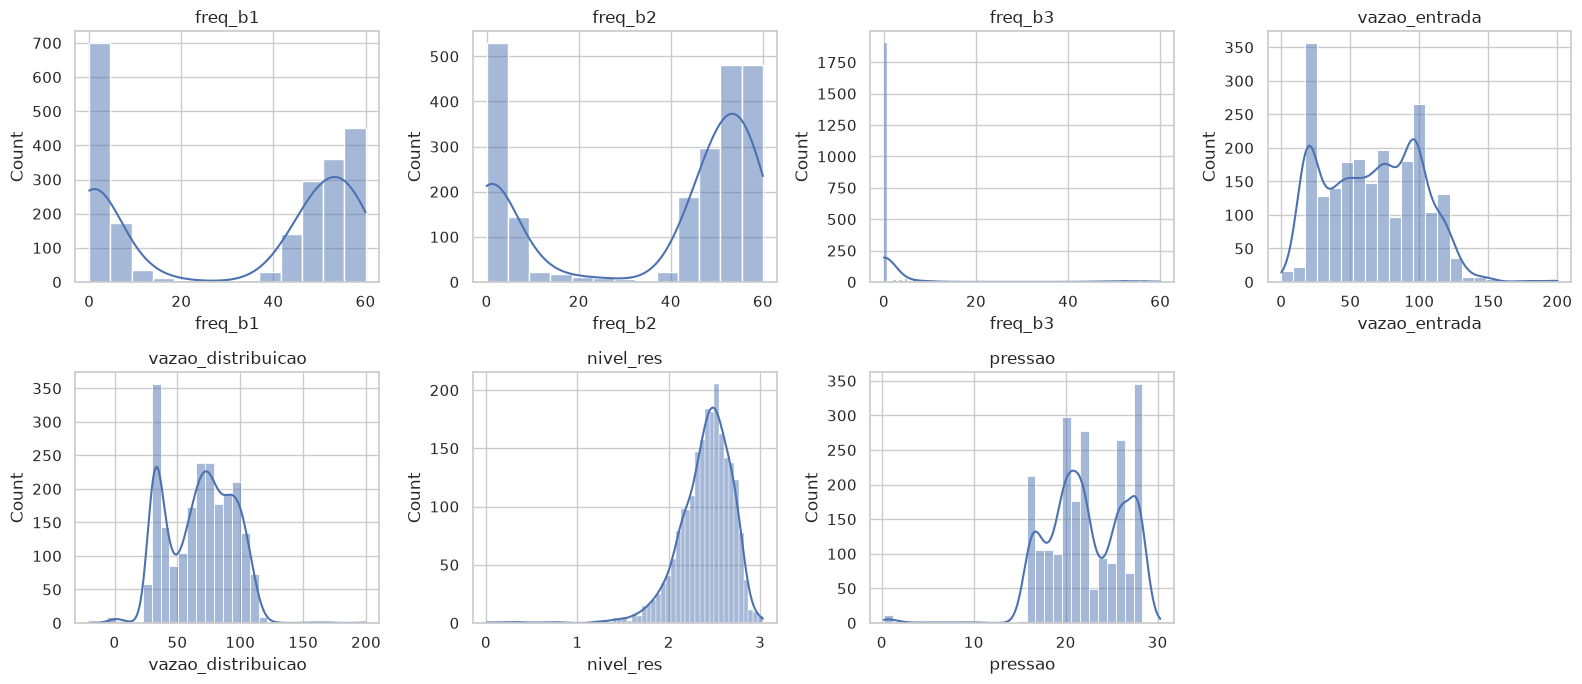

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
cols = inputs + outputs

for ax, col in zip(axes.flat, cols):
    sns.histplot(mimo[col], kde=True, ax=ax)
    ax.set_title(col)

for ax in axes.flat[len(cols) :]:
    ax.set_visible(False)

fig.tight_layout()

### Correlação entre entradas e saídas\n\nO artigo destaca que as saídas têm ordens de grandeza muito diferentes\n(vazões em l/s, nível em m, pressão em mca), o que motiva o uso de\nmetaheurísticas multiobjetivo em vez de agregar tudo em uma única função\nobjetivo.

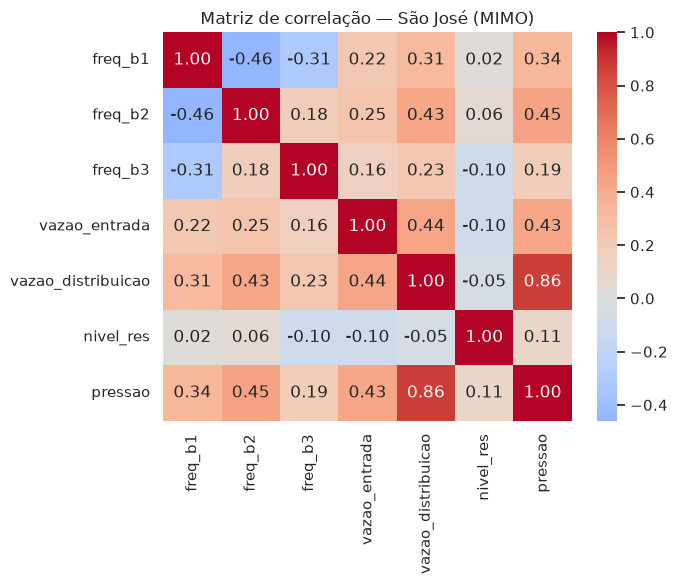

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    mimo.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set_title("Matriz de correlação — São José (MIMO)")
fig.tight_layout()

## 2. Reservatório Tarumã (MISO) — referência\n\nUsado no estudo original [26] citado no artigo como precursor deste trabalho\n(identificação de sistema MISO com metaheurísticas mono-objetivo). Mantido\naqui apenas como referência comparativa; cada bomba tem uma coluna\n`Quality` associada (status do sensor), que descartamos após o filtro.

In [9]:
miso_cols = [
    "timestamp",
    "corr_b1",
    "quality_b1",
    "_blank1",
    "corr_b2",
    "corr_b3",
    "corr_b4",
    "corr_b5",
    "corr_b6",
    "vazao_cajuru",
]

miso_raw = pd.read_excel(
    MISO_PATH, sheet_name="Taruma", header=None, skiprows=2
)
miso = miso_raw.iloc[:, : len(miso_cols)]
miso.columns = miso_cols
miso = miso.drop(columns=["quality_b1", "_blank1"])
miso["timestamp"] = pd.to_datetime(miso["timestamp"], errors="coerce")
miso = miso.dropna(subset=["timestamp"]).set_index("timestamp").sort_index()
miso = miso.apply(pd.to_numeric, errors="coerce")

print(miso.shape)
miso.head()

(2208, 7)


,corr_b1,corr_b2,corr_b3,corr_b4,corr_b5,corr_b6,vazao_cajuru
timestamp,,,,,,,
2014-05-01 01:00:00,0.0,0.0,0.0,398.471191,0.000000,400.0,988.780579
2014-05-01 02:00:00,0.0,0.0,0.0,396.887360,0.000000,400.0,995.427185
2014-05-01 03:00:00,0.0,0.0,0.0,399.418762,399.408691,400.0,1446.112915
2014-05-01 04:00:00,0.0,0.0,0.0,397.931641,397.895782,400.0,1432.196045
2014-05-01 05:00:00,0.0,0.0,0.0,396.444489,396.382843,400.0,1441.959351


In [10]:
print(miso.isna().sum())
miso.describe()

corr_b1         9
corr_b2         9
corr_b3         9
corr_b4         9
corr_b5         9
corr_b6         9
vazao_cajuru    9
dtype: int64


,corr_b1,corr_b2,corr_b3,corr_b4,corr_b5,corr_b6,vazao_cajuru
count,2199.000000,2199.000000,2199.000000,2199.000000,2199.000000,2199.000000,2199.000000
mean,34.329657,72.457724,191.494106,259.121828,258.736378,78.955865,1034.187835
std,97.886469,131.403483,198.736261,188.754942,187.921215,158.594329,496.316995
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,907.764496
50%,0.000000,0.000000,0.000000,394.985748,392.799988,0.000000,1024.000610
75%,0.000000,0.000000,398.096893,398.083176,397.313324,0.000000,1414.829285
max,324.000000,320.000000,400.000000,400.000000,400.000000,400.000000,1875.513550


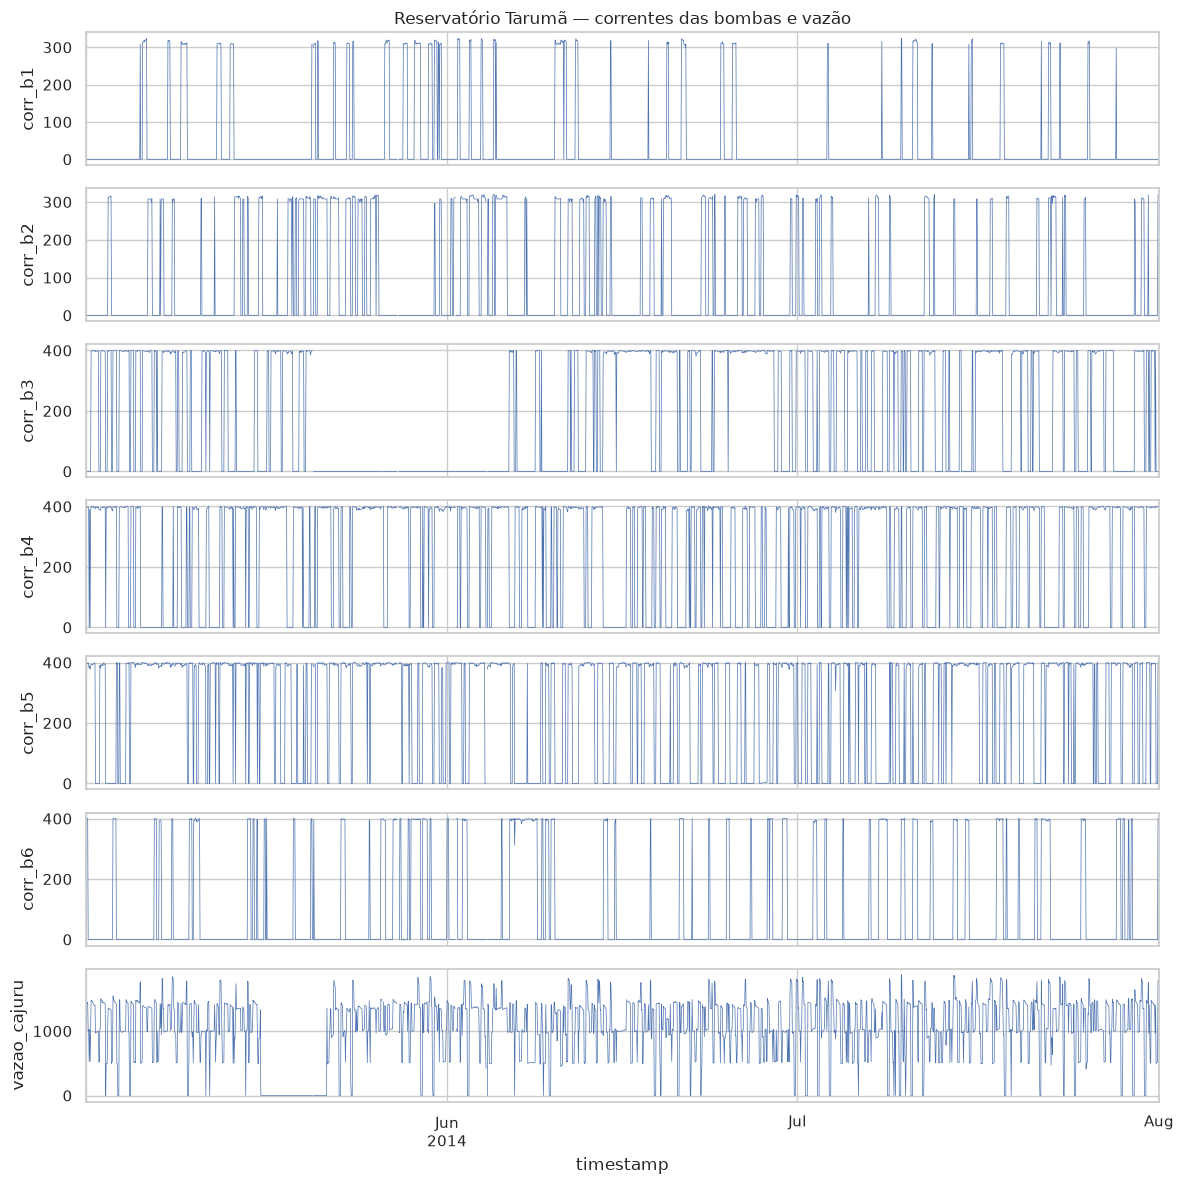

In [11]:
fig, axes = plt.subplots(len(miso.columns), 1, figsize=(12, 12), sharex=True)

for ax, col in zip(axes, miso.columns, strict=True):
    miso[col].plot(ax=ax, linewidth=0.5)
    ax.set_ylabel(col)

axes[0].set_title("Reservatório Tarumã — correntes das bombas e vazão")
axes[-1].set_xlabel("timestamp")
fig.tight_layout()

#### 3. Conclusões da exploração\n\n- O foco de modelagem deste projeto (reprodução do artigo) é o dataset\n  **São José** (`mimo_data.xlsx`): 3 entradas (frequência das bombas) e 4\n  saídas (vazão de entrada, vazão de distribuição, nível e pressão),\n  amostrado a cada hora, sem valores ausentes na amostra inspecionada.\n- As saídas têm escalas muito diferentes entre si (l/s, m, mca), confirmando\n  o ponto do artigo sobre o risco de uma única função objetivo agregada\n  dominar por causa da ordem de grandeza — motivando o uso de\n  metaheurísticas multiobjetivo (NSGA-II, MOGWO, MOCS) na identificação do\n  sistema ARMAX.\n- O dataset **Tarumã** (`miso_data.xls`) é mantido apenas como referência do\n  trabalho anterior (MISO, mono-objetivo) e não é o alvo da reprodução.\n- Próximos passos (fora do escopo deste notebook): tratar `notebooks/processing/`\n  para normalização/particionamento treino-validação e `notebooks/modeling/`\n  para a identificação ARMAX com as metaheurísticas mono e multiobjetivo.